This example uses a fully sampled 64-channel dataset that can be found here: https://huggingface.co/datasets/lyx228/Fully_Sampled_MRI/tree/main.
It is making use of the default config.json file. 

In [1]:
import json
import os

import nibabel as nib

import numpy as np 
import scipy as sp
from scipy.linalg import orth
from scipy.linalg import norm

from skimage.morphology import convex_hull_image 
from skimage.morphology import binary_erosion 

from ROVir import rovir
from ROVir import top_nv
from ROVir import form_virtual_coil_data

from visualization import display_defaced
from visualization import compare_retention
from visualization import show_virtual_coils

from to_nifti import niftify
from automask import gen_mask


import matplotlib


RED = '\033[91m'
GREEN = '\033[92m'
RESET = '\033[0m'

import torch

if(torch.cuda.is_available()):
    print("GPU mode")
    gpu_mode = True
else:
    print("CPU mode")
    gpu_mode = False

CPU mode


The config file used to generate the following results contain the following information:
```
{
    "input_data": {"data_path": "input/test03.npy",
                    "data_id": "03x",
                    "x_y_z_channel": [0, 1, 2, 3],
                    "a11": 1, 
                    "a22": 1,
                    "a33": -1},

    "visualization": {
                    "plt_on": true,
                    "compare_retention": false,
                    "show_virtual_coils": false},

    "coil_selection": {"threshold_method": "face_retained",
                        "threshold_value": 10},

    "masks": {
                "gap": 10},

    "output":{"save_defaced_kspace": false,
            "save_defaced_image": true}
}
```

CPU mode
Data has been successfully loaded
Using predefined masks
Mask has been successfully loaded
Masks have been prepared
Brain and face covariance matrices have been computed
Eigenvectors computed


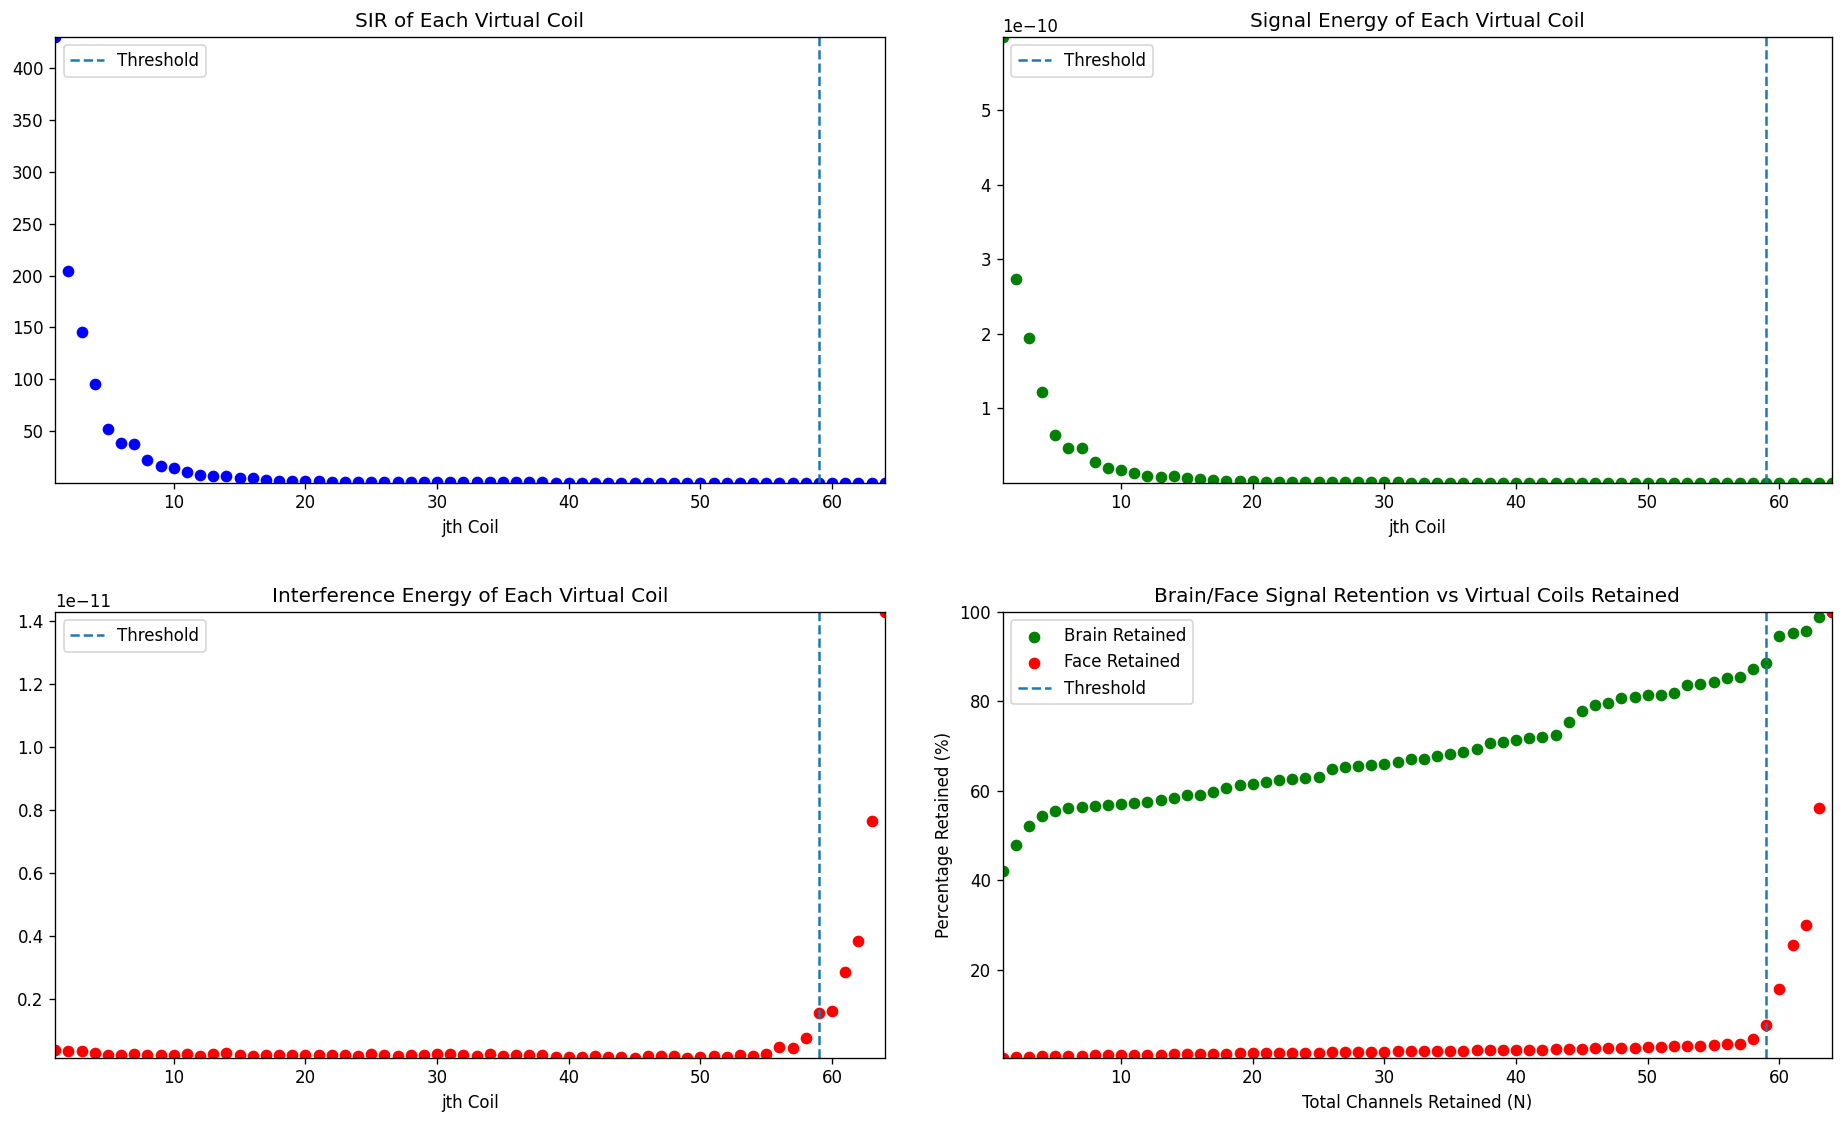

The top nv eigenvectors contain the first 59 eigenvectors
BRAIN SIGNAL RETAINED:88.62273277383082
FACE SIGNAL RETAINED:7.654169862806039
Virtual coils successfully formed


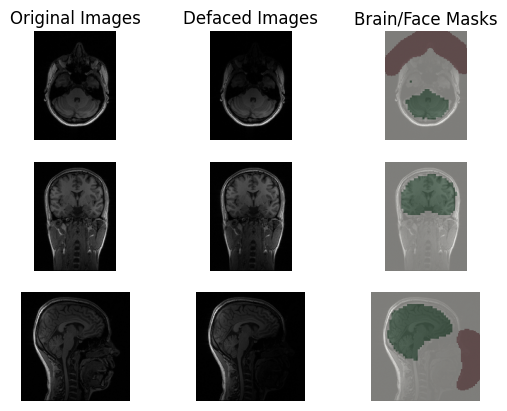

[[  1.   0.   0. -58.]
 [  0.   1.   0. -77.]
 [  0.   0.   1. -77.]
 [  0.   0.   0.   1.]]
Nifti file successfully saved


In [2]:
%matplotlib inline

from raw_deface import run_raw_deface
run_raw_deface('config2.json')

You can use different mask manipulation schemes by selecting an option in the config.json file. The following outputs are generated with the below config file. Mask manipulation option A is visualized in this example. 
```
{
    "input_data": {"data_path": "input/test03.npy",
                    "data_id": "03x",
                    "x_y_z_channel": [0, 1, 2, 3],
                    "a11": 1, 
                    "a22": 1,
                    "a33": -1},

    "visualization": {
                    "plt_on": true,
                    "compare_retention": false,
                    "show_virtual_coils": false},

    "coil_selection": {"threshold_method": "face_retained",
                        "threshold_value": 10},

    "masks": {"manipulation": "A",
                "gap": 10},

    "output":{"save_defaced_kspace": false,
            "save_defaced_image": true}
}

```

CPU mode
Data has been successfully loaded
Using predefined masks
Mask has been successfully loaded
Masks have been prepared
Brain and face covariance matrices have been computed
Eigenvectors computed


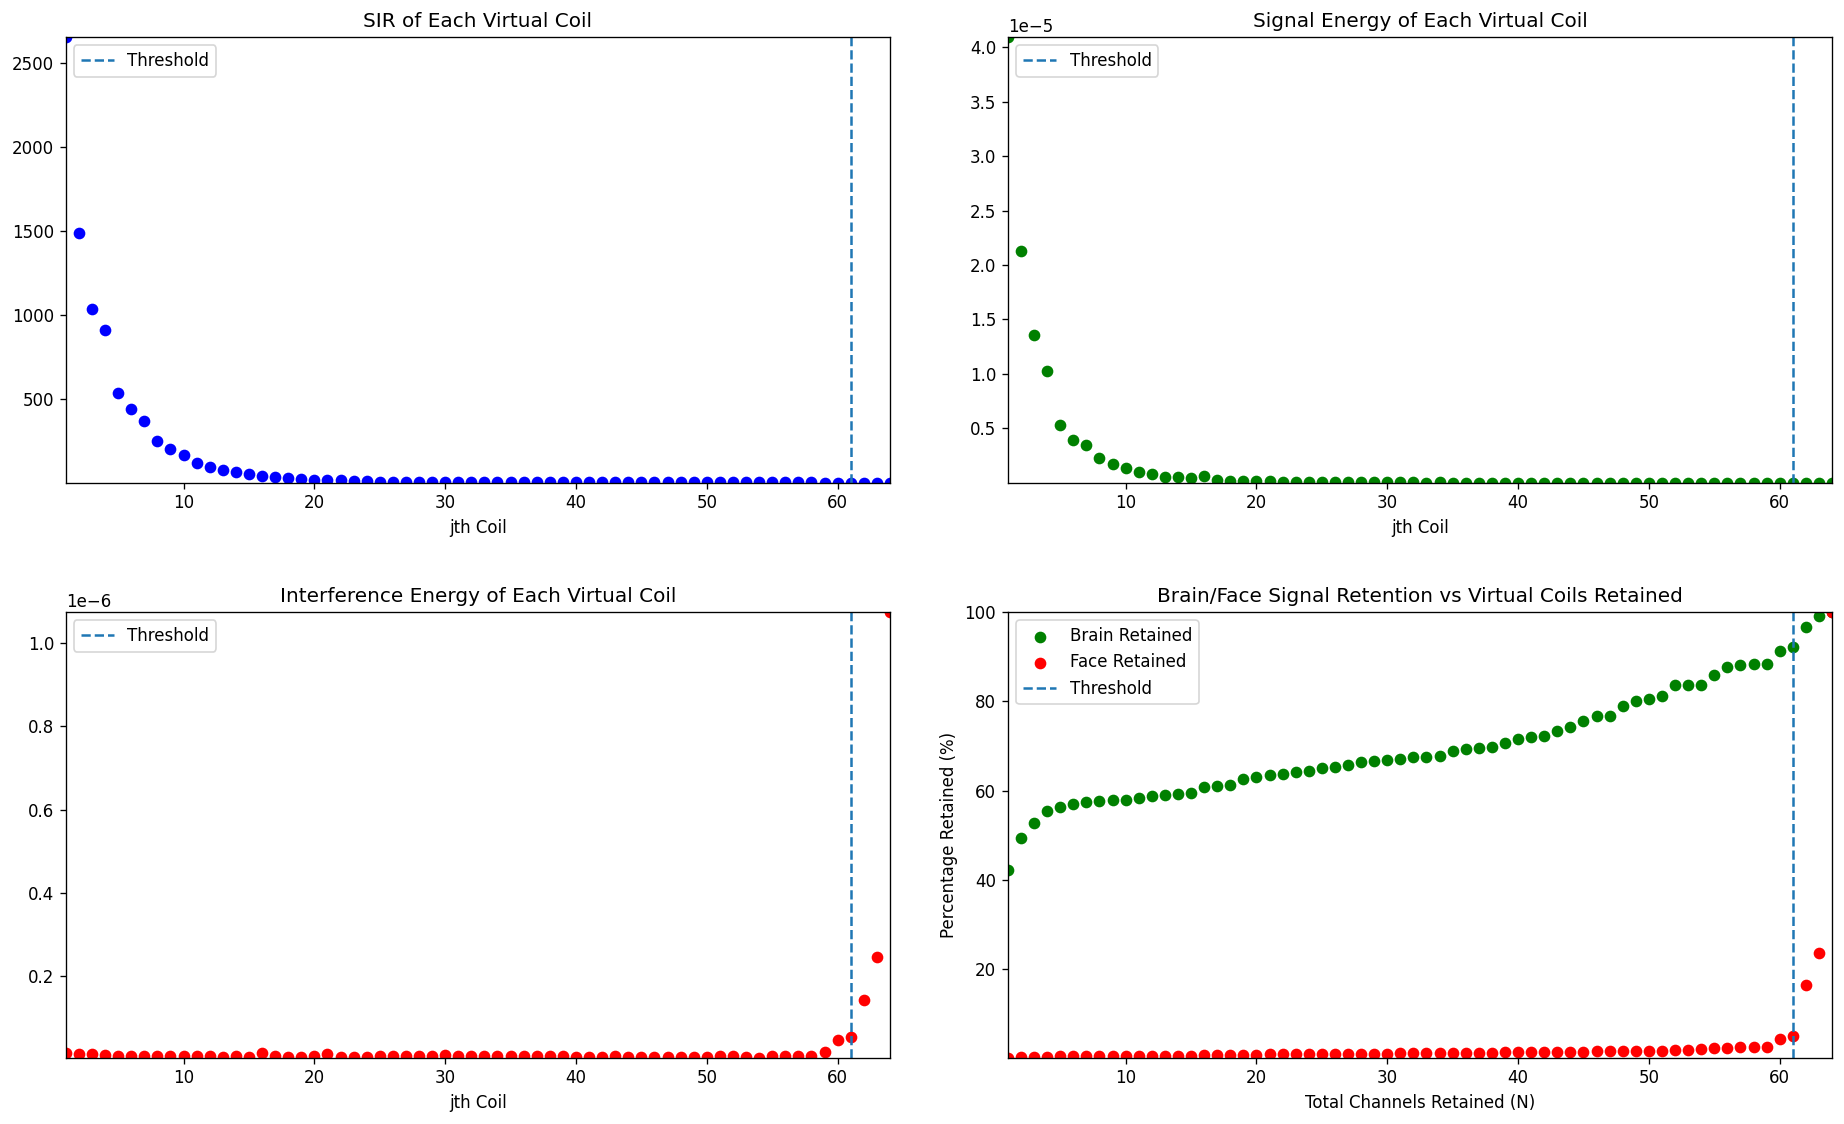

The top nv eigenvectors contain the first 61 eigenvectors
BRAIN SIGNAL RETAINED:92.11622946057581
FACE SIGNAL RETAINED:5.0644720563661565
Virtual coils successfully formed


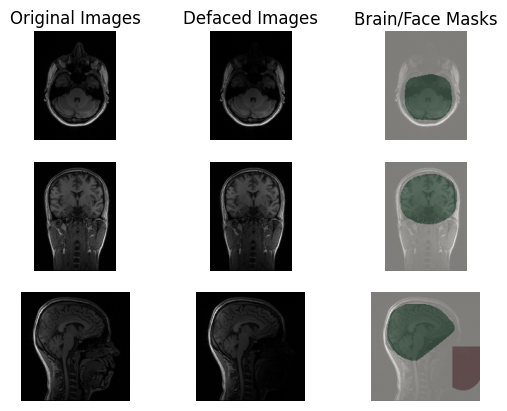

[[  1.   0.   0. -58.]
 [  0.   1.   0. -77.]
 [  0.   0.   1. -77.]
 [  0.   0.   0.   1.]]
Nifti file successfully saved


In [2]:
%matplotlib inline

from raw_deface import run_raw_deface
run_raw_deface('config2.json')